In [ ]:
### Runlog for TimeScaling

# N = 5k: 
# S = 0.01: 54 s
# S = 0.05: 43 s
# S = 0.10: 40 s
# S = 0.15: 52 s

# N = 10k:
# S = 0.01: 139 s
# S = 0.05: 103 s
# S = 0.10: 300 s

# N = 20k: 
# S = 0.05: 180+ s
# S = 0.01: 139 s
# S = 0.03: 180+ s

# N = 50k:
# S = 0.0050: 12 min 17 s
# S = 1.0000: 38 min
# S = 0.0025: 14+ min


0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000


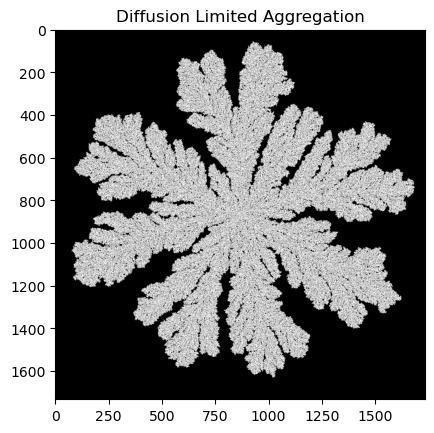

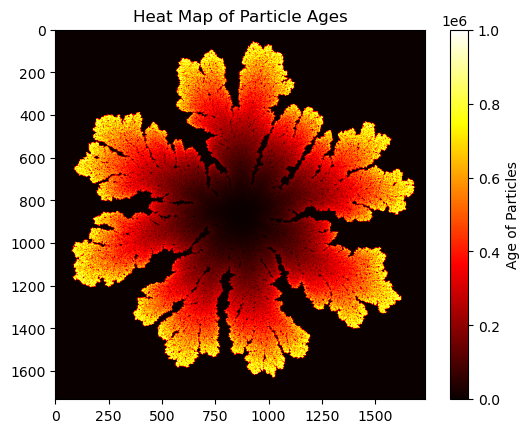

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


spawn_radius = 21
length = 52


heat = np.zeros((length, length))                         # tracks age of particles


                                                          # v changed 100 to 101 so the seed is actually centered
space = np.zeros((length, length), dtype=bool)            # boolean array to represent discrete 2D space (102x102 blocks): True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle



seed = True


def spawn(radius):
    theta = np.random.uniform(0, 2 * np.pi)                                                                 # generates a random angle between 0 and 2pi
    x, y = int(radius * np.cos(theta)), int(radius * np.sin(theta))
    return x, y


def find_rmax(i, x, y):
    global length, space, heat, spawn_radius, r_max                      # I should probably pass these later but rn Im just testing stuff
   
    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2)) + 1               # distance from the center seed

    if i == 0:
        r_max = 1

    elif r_i > r_max:
        r_max = r_i

    return r_max

def resizing_circle(i, x, y):                                                  # spawn points        
    ##############################################
    # Adaptive resizing
    global length, space, heat, spawn_radius                                         # I should probably pass these later but rn Im just testing stuff
   
    r_max = find_rmax(i, x, y)

    if spawn_radius < r_max + 5:
        new_radius = r_max + 5
        x, y = spawn(new_radius)    
        spawn_radius = new_radius  

def resizing_square(i, x, y):                                                  # boundaries
    ##############################################
    # Adaptive resizing
    global length, space, heat                                          # I should probably pass these later but rn Im just testing stuff
   
    r_max =find_rmax(i, x, y)
    if length < (2 * r_max) + 20:                                              # condition to adjust length
        new_length = length + 20
        if new_length % 2 == 0:                                         # ensures new length is odd so seed can remain centered
            new_length += 1

        new_space = np.zeros((new_length, new_length), dtype=bool)      # adjusts space to new length dimensions
        new_heat = np.zeros((new_length, new_length))                   # adjusts heat to new length dimensions

        shift = (new_length - length) // 2                              # shift such that the space expands outwards from center

        crystal_indices = np.argwhere(space)                            # ^ adjusts space such that it adds space outwards from center
        for x, y in crystal_indices:
            new_space[x + shift, y + shift] = True
            new_heat[x + shift, y + shift] = heat[x, y]
       
        length = new_length                                             # updates length
        space = new_space                                               # updates space
        heat = new_heat                                                 # updates heat

    ##############################################

def kill(i, x, y):
    global length, space, heat, spawn_radius                                              # I should probably pass these later but rn Im just testing stuff

    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2)) + 1               # distance from the center seed

    if r_i > spawn_radius * 3:
        return True
    else:
        return False


def random_walk(i):
    global length, space, heat, spawn_radius                                              # I should probably pass these later but rn Im just testing stuff

    if i % 10000 == 0:
        print(i)

    x, y = spawn(spawn_radius)                                                            # spawns particle at random point on circle
    x += length // 2                                                                # aligns circle to be centered at the seed
    y += length // 2                                                                # aligns circle to be centered at the seed  


    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = random.getrandbits(2)
       
        new_x, new_y = x, y

        if direction == 0:
            new_y += 1
        elif direction == 1:
            new_y -= 1
        elif direction == 2:
            new_x -= 1
        else:
            new_x += 1

        if 0 < new_x < length-1 and 0 < new_y < length-1 and not space[new_x, new_y]:
            x, y = new_x, new_y
       
        if kill(i, x, y):                                                          # checks if particle is too far from the seed and kills it if it is
            x, y = spawn(spawn_radius)                                                    # respawns particle at random point on circle
            x += length // 2                                                            # aligns circle to be centered at the seed
            y += length // 2                                                            # aligns circle to be centered at the seed
            continue                                                    

        # Check if particle is next to the seed (3x3 neighborhood)
                                                                                # checks 3x3 neighborhood for crystal
        if 0 < x < length-1 and 0 < y < length-1:                           # only checks if particle is not on the edge to avoid errors (aggregate does not approach edge so this is fine)
            if ((space[x-1, y] or space[x,   y-1] or space[x, y+1]
                or space[x+1, y]) and not space[x, y]):                         # ensures spot is not already occupied

                if np.random.rand() < stickiness:                               # Chance of sticking to the seed is the stickiness factor
                    space[x, y] = seed
                    heat[x, y] = i + 1                                          # tracks the age of the particle that sticks to the seed
                    resizing_square(i, x, y)
                    resizing_circle(i, x, y)
                    break                                                       # moved break inside the if so it only breaks if the particle sticks



# DLA Simulation + Animation
x, y = spawn(spawn_radius)


N = 1000000
stickiness = 0.005

for i in range(N):
    random_walk(i)


# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()

# plot heat map
plt.imshow(heat, cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()

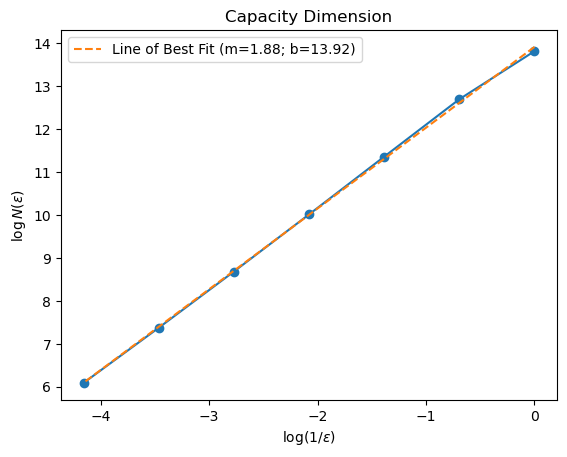

In [2]:
# Capacity Dimension Calculation

def box_partitioning(space, delta_length):
    length = space.shape[0]                     # same as len but for higher dimension arrays
    count = 0
    for i in range(0, length, delta_length):        # delta_length = box length
        for j in range(0, length, delta_length):
            if np.any(space[i:i+delta_length, j:j+delta_length]):   # checks the slice of space from the edge of box the the next edge if there are any "true" or 1s in it
                count += 1
    return count

delta_lengths = [1, 2, 4, 8, 16, 32, 64]             # side lengths of boxes
counts = [box_partitioning(space, size) for size in delta_lengths]
log_counts = np.log(counts)
log_sizes = np.log(1/np.array(delta_lengths))

fit=np.polyfit(log_sizes, log_counts, 1)  
capacity_dimension = fit[0]        
b = fit[1]

overlay = capacity_dimension * log_sizes + b

plt.plot(log_sizes, log_counts, marker='o')
plt.plot(log_sizes, overlay, '--' ,label=f'Line of Best Fit (m={capacity_dimension:.2f}; b={b:.2f})')
plt.title('Capacity Dimension')
plt.xlabel(r'$\log(1/\epsilon)$')
plt.ylabel(r'$\log N(\epsilon)$')
plt.legend()
plt.show()

Fractal dimension: 1.8776624585078685


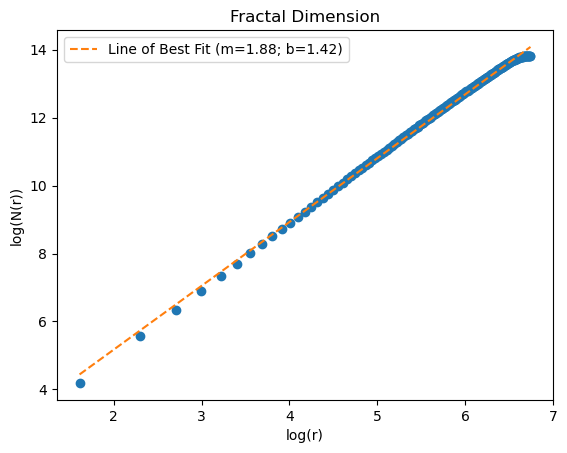

In [3]:
# log N(R) vs log R plot where the slope should be consistent with the fractal dimension
aggregate = np.argwhere(space)

# center
x_0 = length // 2
y_0 = length // 2

# radius
r = np.sqrt((aggregate[:,0] - x_0)**2 + (aggregate[:,1] - y_0)**2)


r_array = np.arange(5, int(r.max()) + 1, 5)                             # radii starting at r = 5 to r_max (basically) with increments of 5
N_array = [np.sum(r <= R) for R in r_array]                             # Number of occupied blocks from center to radius

log_r = np.log(r_array)
log_N = np.log(N_array)

fit = np.polyfit(log_r, log_N, 1)
slope = fit[0]                              # Fractal dimension (Not the same as capacity dimension I think?)
b = fit[1]

print(f"Fractal dimension:", slope)

overlay = slope * log_r + b

plt.figure()
plt.plot(log_r, log_N, 'o')
plt.plot(log_r, overlay, '--' ,label=f'Line of Best Fit (m={slope:.2f}; b={b:.2f})')
plt.xlabel('log(r)')
plt.ylabel('log(N(r))')
plt.title('Fractal Dimension')
plt.legend()
plt.show()